# Churn Modelling


### Problem statment :

The dataset analyzes bank customer churn, focusing on customer demographics, financial behavior, and account activity to predict if a customer will leave the bank (Exited: 1 for churn, 0 otherwise). It supports insights for customer retention and churn prediction.

### Objectives:


The objective of this model is to predict customer churn (whether a customer will leave the bank or not) based on their demographic, financial, and account activity data. This helps the bank take proactive measures to improve customer retention and minimize churn.

### Reseasrch Question 

What factors influence customer churn in the bank, and how can we accurately predict which customers are at risk of leaving?

### Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns
import re
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

### Loading the dataset

In [4]:
df=pd.read_csv(r"C:\Users\Prime\Desktop\rutuja\Churn_Modelling (1).csv")

In [10]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [16]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

### Data Cleaning:

### Exploratary Data Analysis

In [18]:
df.shape

(10000, 14)

In [20]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [31]:
df.isnull().sum()  #Checking the missing value

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [24]:
#df = df.dropna()  # Drop rows or fill missing values (if any)

In [33]:
# Define a function to check for special characters in a column
def check_special_characters(column):
    pattern = re.compile(r'[^\w\s]')  # Matches any character that is not alphanumeric or whitespace
    return column.apply(lambda x: bool(pattern.search(str(x))))

# Check textual columns for special characters
special_characters = {
    "Surname": check_special_characters(df["Surname"]).any(),
    "Geography": check_special_characters(df["Geography"]).any(),
    "Gender": check_special_characters(df["Gender"]).any()
}

special_characters


{'Surname': True, 'Geography': False, 'Gender': False}

In [28]:
df.Surname.value_counts()

Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64

In [35]:
# Remove special characters from the 'Surname' column
df['Surname'] = df['Surname'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s]', '', str(x)))

# Display the updated dataset (first 5 rows for preview)
df.head()



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Checking Duplicates records

In [32]:
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [37]:
# Check for duplicate rows
duplicates = df.duplicated()

# Count the number of duplicate rows
num_duplicates = duplicates.sum()

num_duplicates


0

### Drops unnecessary columns

In [77]:
df = df.drop(['RowNumber','CustomerId','Surname'])


KeyError: "['RowNumber', 'CustomerId', 'Surname'] not found in axis"

In [67]:
df1.sample(3)

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8905,36,3,0.00,1,0,1,144078.02,0
4847,23,5,104822.45,1,0,1,160176.47,0
4444,31,7,139395.08,1,0,1,6120.84,0


### Data Visualization

#### Churn Analysis:

<Axes: xlabel='Geography', ylabel='Exited'>

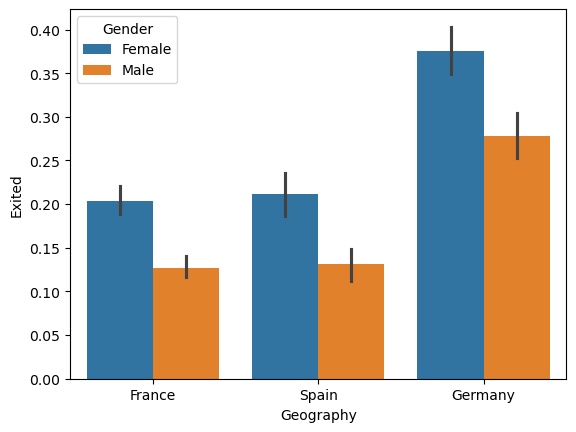

In [43]:
sns.barplot(df, x='Geography', y='Exited', hue = 'Gender' )

Conclusion :
The bar chart displays the proportion of customers who exited (churned) from a service, segmented by geography (France, Spain, Germany) and gender (female, male). Here are the key conclusions from the graph:

Overall Churn Rate by Geography:

Germany has the highest overall churn rate, followed by Spain and then France.
Churn Rate by Gender:

In all three countries, the churn rate is higher for females compared to males.
The difference in churn rate between females and males is most pronounced in Germany and least pronounced in France.
Gender-Specific Insights:

For females, the churn rate is highest in Germany, followed by Spain, and lowest in France.
For males, the churn rate is also highest in Germany, but the rates for France and Spain are quite similar, with France having a slightly higher churn rate.



In [45]:
# Pie Chart: Proportion of customers who churned vs. stayed
#plt.figure(figsize=(6, 6))
df['exited'].value_counts().plot.pie(
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "salmon"],
    explode=[0, 0.1],
    shadow=True
)
plt.title("Proportion of Customers Who Churned vs. Stayed")
#plt.ylabel('')  # Remove y-axis label for better aesthetics
plt.show()


KeyError: 'exited'

### Financial Behavior:

In [1]:
sns.histplot(df,x='Balance',hue="Gender",kde='True')

NameError: name 'sns' is not defined

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

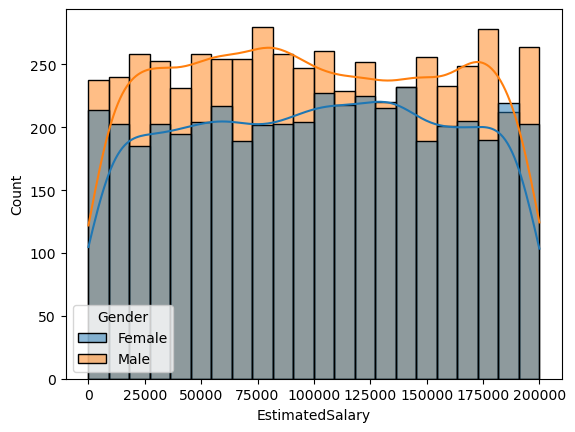

In [49]:
sns.histplot(df,x='EstimatedSalary',hue="Gender",kde='True')

Conclusion :

The bar chart shows the distribution of customers' estimated salaries segmented by gender (female and male). Here are the key conclusions from the graph:

Overall Salary Distribution:

The estimated salary distribution is relatively uniform across different salary ranges for both genders, with slight fluctuations.
Gender-Specific Insights:

For most salary ranges, the count of male customers is higher than that of female customers.
The density lines indicate that male customers generally have a more consistent distribution across different salary ranges compared to female customers.
Peak Counts:

The highest counts for both genders are seen around the middle salary ranges (75,000 to 150,000).


<Axes: xlabel='Balance', ylabel='Geography'>

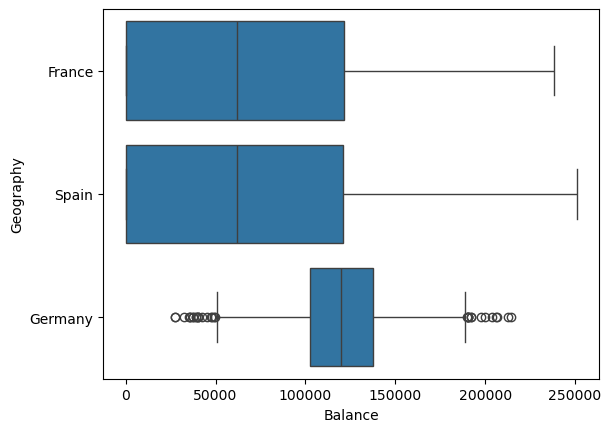

In [51]:
sns.boxplot(df,x='Balance',y='Geography')

Conclusion :
The box plot displays the distribution of account balances by geography (France, Spain, Germany). Here are the key conclusions:

Median Balance:

The median balance is similar for customers in France and Spain, both around 100,000.
The median balance for customers in Germany is higher, close to 125,000.
Interquartile Range (IQR):

France and Spain have a similar IQR, indicating a wide range of balances.
Germany has a narrower IQR, suggesting less variability in account balances.
Outliers:

Germany has several outliers with lower balances, indicating some customers with significantly lower balances compared to the rest.
Overall Range:

The overall range of balances (from minimum to maximum) is widest in France, followed by Spain, and narrowest in Germany.

<Axes: xlabel='Balance', ylabel='EstimatedSalary'>

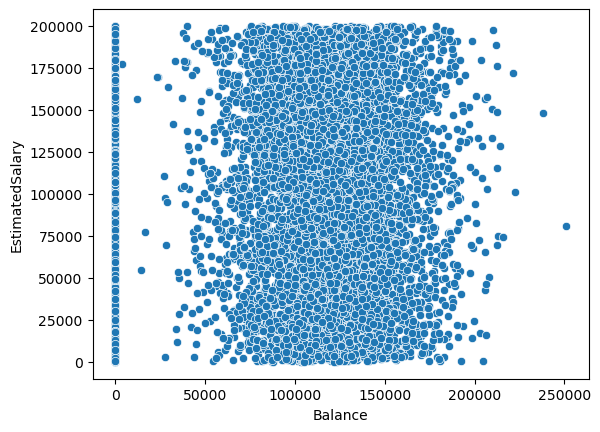

In [8]:
sns.scatterplot(df,x='Balance',y='EstimatedSalary')

Conclusion:
The Scatter plot displays the distribution of balances and Estimatedsalary. There is no relation between balance and Estimatedsalary as shown abouve the gharphs balance varies 50000 to 200000 as th across of the Estimatedsalary.


### Customer Demographics:

<Axes: xlabel='Age', ylabel='Density'>

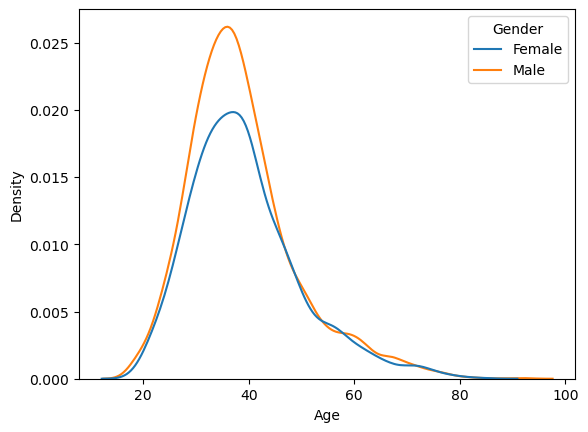

In [13]:
sns.kdeplot(df,x='Age',hue='Gender')

In [ ]:
Conclusion: 
This Kdeplot between Age and Density while in gender coloumn,Male get more value upto 0.025 and
Female gets inbetween 0.015 and 0.020 across the age.


In [79]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [87]:
df1=df.iloc[::,6::]
df1

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,42,2,0.00,1,1,1,101348.88,1
1,41,1,83807.86,1,0,1,112542.58,0
2,42,8,159660.80,3,1,0,113931.57,1
3,39,1,0.00,2,0,0,93826.63,0
4,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...
9995,39,5,0.00,2,1,0,96270.64,0
9996,35,10,57369.61,1,1,1,101699.77,0
9997,36,7,0.00,1,0,1,42085.58,1
9998,42,3,75075.31,2,1,0,92888.52,1


In [89]:
df1.corr()

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Age,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


<Axes: >

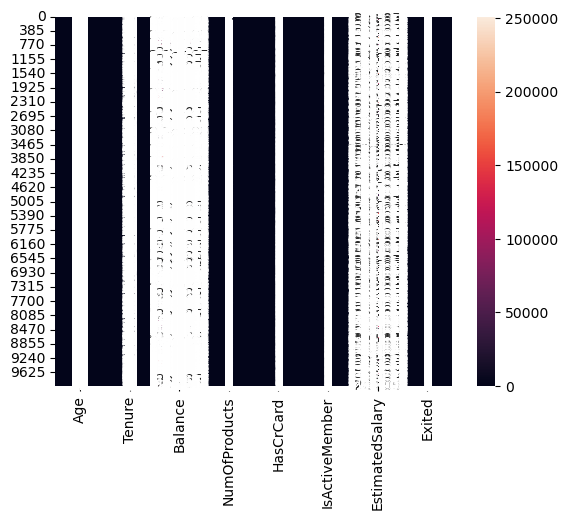

In [95]:
sns.heatmap(df1, annot=True)